<a href="https://colab.research.google.com/github/BrajanNieto/CompuVision/blob/main/CV_Labo5_UNET_Inpaiting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Computer Vision – Inpainting de imágenes con UNet**

---

* Este script implementa un sistema completo de inpainting de imágenes de mascotas utilizando una arquitectura UNet en PyTorch. Primero se construye el `PetInpaintingDataset`, que combina imágenes RGB de mascotas con máscaras irregulares para generar pares de entrada–salida: una imagen con regiones ocultas y su correspondiente imagen completa. Luego, el conjunto de datos se divide en subconjuntos de entrenamiento, validación y prueba, y se preparan `DataLoader` para cada uno. Sobre esta base, se define una UNet para reconstruir imágenes RGB, se entrena el modelo usando pérdida L1 y se evalúa la calidad de las reconstrucciones mediante la métrica PSNR. Finalmente, se guardan los mejores pesos del modelo y se generan visualizaciones cualitativas que comparan la imagen con huecos, la salida del modelo y la imagen objetivo original.*

**Tecnologías y componentes clave:**

- Definición de un dataset de inpainting con máscaras irregulares (`PetInpaintingDataset`).
- División en *train/val/test* y carga eficiente con `DataLoader`.
- Implementación de una arquitectura UNet para reconstrucción de imágenes RGB.
- Entrenamiento con pérdida L1 y cálculo de PSNR como métrica de calidad.
- Guardado del mejor modelo según PSNR en validación.
- Visualización de resultados cualitativos con `matplotlib`.



**Autores:**  

Nieto Espinoza, Brajan E.  
[brajan.nieto@utec.edu.pe](mailto:brajan.nieto@utec.edu.pe)

Guedes del Pozo,  Rodrigo J.  
[rodrigo.guedes.d@utec.edu.pe](mailto:rodrigo.guedes.d@utec.edu.pe)

<img src="https://pregrado.utec.edu.pe/sites/default/files/logo-utec-h_0_0.svg" width="190" alt="Logo UTEC" loading="lazy" typeof="foaf:Image">      

---

### **0.** Clonación del dataset e importación de librerías

Se incluyen módulos para:
- Manejo de rutas y archivos (`os`, `Path`, `random`, `math`).
- Procesamiento y visualización de datos (`NumPy`, `matplotlib`, `PIL`).
- Construcción de datasets, modelos y entrenamiento con PyTorch (`torch`, `torchvision`, `tqdm`).


In [17]:
# Clonar Dataset
!git clone https://github.com/BrajanNieto/CompuVision.git

# Librerías
import os
from pathlib import Path
import random
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm.auto import tqdm

### **1.** Preparación del Dataset
Esta celda define la clase `PetInpaintingDataset`, responsable de preparar los datos para el modelo de *inpainting*.  

Cada muestra del dataset incluye:
- **image_complete**: imagen original sin alteraciones.  
- **image_with_holes**: imagen con partes ocultas usando una máscara irregular.  
- **mask**: máscara binaria donde `1 = conservar` y `0 = hueco`.  
- **mask_inverted**: la versión invertida (`1 = hueco`).  

La clase:
- Carga todas las imágenes y máscaras.
- Redimensiona y transforma imágenes/máscaras a tensores.
- Escoge una máscara aleatoria para cada imagen.
- Devuelve un diccionario con todos los elementos necesarios para entrenamiento y visualización.

Al final, se instancia el dataset y se crea un `DataLoader` con `batch_size=4` para iterar de forma eficiente durante el entrenamiento.


In [ ]:
# Rutas a tu dataset
DATA_DIR = Path("CompuVision/pet_dataset")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "irregular_masks"

class PetInpaintingDataset(Dataset):
    """
    Devuelve:
      - image_with_holes: imagen RGB con huecos (entrada a la UNet)
      - image_complete: imagen RGB original (target)
      - mask_inverted: 1 = hueco, 0 = conservar (útil para visualizar)
    """
    def __init__(self, image_paths, masks_dir, img_size=(256, 256)):
        self.image_paths = image_paths
        self.masks_dir = masks_dir
        self.img_size = img_size

        self.mask_paths = sorted([
            masks_dir / f for f in os.listdir(masks_dir)
            if f.lower().endswith(".png")
        ])

        self.img_transform = T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
        ])

        self.mask_transform = T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)


        mask_path = random.choice(self.mask_paths)
        mask = Image.open(mask_path).convert("L")
        mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()

        image_with_holes = img * mask

        mask_inverted = 1.0 - mask

        return image_with_holes, img, mask_inverted

# Dataloader
dataset = PetInpaintingDataset(
    images_dir="/content/CompuVision/pet_dataset/images",
    masks_dir="/content/CompuVision/pet_dataset/irregular_masks",
    img_size=(256, 256)
)

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

### **2.** Visualización de Datos

Esta celda toma un batch del `DataLoader` y selecciona el primer ejemplo para visualizarlo. Permite verificar que el dataset está funcionando correctamente antes de entrenar el modelo.  

La celda realiza tres acciones principales:

1. **Extrae tensores** del batch:  
   - `image_with_holes`: imagen con huecos aplicada por la máscara.  
   - `image_complete`: imagen objetivo sin modificaciones.  
   - `mask_inverted`: máscara donde `1 = hueco`, útil para inspección.

2. **Convierte los tensores a formato NumPy** para poder graficarlos con `matplotlib`.

3. **Muestra tres imágenes lado a lado**:  



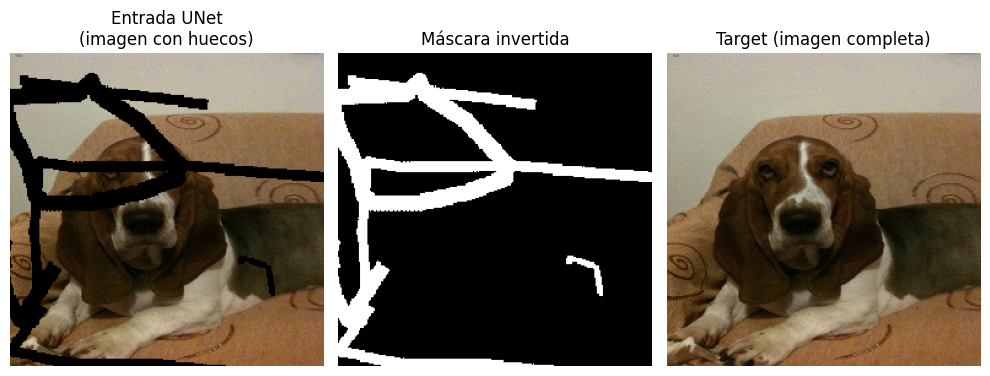

In [6]:
batch = next(iter(dataloader))

image_with_holes = batch["image_with_holes"][0]
image_complete = batch["image_complete"][0]
mask_inverted = batch["mask_inverted"][0]

def to_np_img(t):
    return t.permute(1, 2, 0).cpu().numpy()

img_holes_np = to_np_img(image_with_holes)
img_full_np = to_np_img(image_complete)
mask_inv_np = mask_inverted.squeeze(0).cpu().numpy()  # (H,W)

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_holes_np)
plt.title("Entrada UNet\n(imagen con huecos)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_inv_np, cmap="gray")
plt.title("Máscara invertida")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_full_np)
plt.title("Target (imagen completa)")
plt.axis("off")

plt.tight_layout()
plt.show()


### División del dataset y configuración de entrenamiento

En esta celda se realiza la preparación del conjunto de datos y la configuración básica del entrenamiento:

- **Listar y dividir imágenes**:  
  Se listan todas las imágenes disponibles en `IMAGES_DIR`, se mezclan aleatoriamente y se dividen en tres subconjuntos:
  - 80% para entrenamiento (`train_paths`)
  - 10% para validación (`val_paths`)
  - 10% para prueba (`test_paths`)

- **Configuración del experimento (`CFG`)**:  
  Se definen hiperparámetros clave como:
  - Tamaño de batch (`BATCH`)
  - Número máximo de épocas (`EPOCHS`)
  - Tasa de aprendizaje (`LR`)
  - Tamaño de imagen (`IMG_SIZE`)
  - Número de *workers* para los `DataLoader`
  - Semilla aleatoria (`SEED`) para reproducibilidad

In [8]:
# Listar todas las imágenes
all_imgs = sorted([
    IMAGES_DIR / f for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

random.shuffle(all_imgs)
n_total = len(all_imgs)
train_end = int(0.8 * n_total)
val_end = int(0.9 * n_total)

train_paths = all_imgs[:train_end]
val_paths   = all_imgs[train_end:val_end]
test_paths  = all_imgs[val_end:]

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# Configuración
CFG = {
    "BATCH": 8,
    "EPOCHS": 50,      #  50 épocas
    "LR": 1e-4,
    "IMG_SIZE": 256,
    "NUM_WORKERS": 2,
    "SEED": 22,
}

def seed_everything(seed=22):
    import numpy as np, torch, random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Datasets
train_ds = PetInpaintingDataset(train_paths, MASKS_DIR, img_size=(CFG["IMG_SIZE"], CFG["IMG_SIZE"]))
val_ds   = PetInpaintingDataset(val_paths,   MASKS_DIR, img_size=(CFG["IMG_SIZE"], CFG["IMG_SIZE"]))
test_ds  = PetInpaintingDataset(test_paths,  MASKS_DIR, img_size=(CFG["IMG_SIZE"], CFG["IMG_SIZE"]))

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=CFG["BATCH"], shuffle=True,
                          num_workers=CFG["NUM_WORKERS"])
val_loader   = DataLoader(val_ds,   batch_size=CFG["BATCH"], shuffle=False,
                          num_workers=CFG["NUM_WORKERS"])
test_loader  = DataLoader(test_ds,  batch_size=CFG["BATCH"], shuffle=False,
                          num_workers=CFG["NUM_WORKERS"])

batch = next(iter(train_loader))
print("Shapes →",
      "input:", batch[0].shape,
      "target:", batch[1].shape,
      "mask_inv:", batch[2].shape)


Train: 532 | Val: 66 | Test: 67
Device: cuda
Shapes → input: torch.Size([8, 3, 256, 256]) target: torch.Size([8, 3, 256, 256]) mask_inv: torch.Size([8, 1, 256, 256])


### Definición de la arquitectura UNet

En esta celda se define la arquitectura de la red neuronal, igual al ejemplo de clase:

- **`DoubleConv`**: bloque básico que aplica dos convoluciones 2D seguidas de normalización por lotes y activación ReLU. Se usa como unidad principal tanto en el encoder como en el decoder.
- **`UNet`**: implementación de una UNet clásica con:
  - **Encoder**: cuatro bloques `DoubleConv` con *max pooling* para extraer características a diferentes escalas.
  - **Bottleneck**: bloque central que capta la representación más comprimida de la imagen.
  - **Decoder**: capas de *upsampling* (transposed convolutions) combinadas con *skip connections* del encoder para recuperar la resolución espacial.
  - **`out_conv`**: capa final de convolución 1×1 que ajusta el número de canales de salida (`n_classes`).

Al final de la celda se instancia el modelo, se mueve al dispositivo correspondiente (`cpu` o `cuda`) y se imprime el número total de parámetros en millones, para tener una referencia del tamaño de la red.


In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_classes=1, base_c=64):
        super().__init__()
        self.d1 = DoubleConv(3, base_c)
        self.d2 = DoubleConv(base_c, base_c * 2)
        self.d3 = DoubleConv(base_c * 2, base_c * 4)
        self.d4 = DoubleConv(base_c * 4, base_c * 8)

        self.maxpool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_c * 8, base_c * 16)

        self.up4 = nn.ConvTranspose2d(base_c * 16, base_c * 8, kernel_size=2, stride=2)
        self.u4 = DoubleConv(base_c * 16, base_c * 8)
        self.up3 = nn.ConvTranspose2d(base_c * 8, base_c * 4, kernel_size=2, stride=2)
        self.u3 = DoubleConv(base_c * 8, base_c * 4)
        self.up2 = nn.ConvTranspose2d(base_c * 4, base_c * 2, kernel_size=2, stride=2)
        self.u2 = DoubleConv(base_c * 4, base_c * 2)
        self.up1 = nn.ConvTranspose2d(base_c * 2, base_c, kernel_size=2, stride=2)
        self.u1 = DoubleConv(base_c * 2, base_c)

        self.out_conv = nn.Conv2d(base_c, n_classes, 1)

    def forward(self, x):
        # Encoder
        x1 = self.d1(x)
        x2 = self.d2(self.maxpool(x1))
        x3 = self.d3(self.maxpool(x2))
        x4 = self.d4(self.maxpool(x3))

        # Bottleneck
        xb = self.bottleneck(self.maxpool(x4))

        # Decoder
        x = self.up4(xb)
        x = torch.cat([x4, x], dim=1)
        x = self.u4(x)

        x = self.up3(x)
        x = torch.cat([x3, x], dim=1)
        x = self.u3(x)

        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.u2(x)

        x = self.up1(x)
        x = torch.cat([x1, x], dim=1)
        x = self.u1(x)

        return self.out_conv(x)

model = UNet().to(device)
print("Parámetros:", sum(p.numel() for p in model.parameters())/1e6, "M")

Parámetros: 31.037633 M


In [11]:
class InpaintingUNet(UNet):
    def __init__(self, base_c=32):
        # n_classes=3 por 3 canales
        super().__init__(n_classes=3, base_c=base_c)

# Instanciar el modelo
inpaint_model = InpaintingUNet(base_c=32).to(device)
print("Parámetros (M):", sum(p.numel() for p in inpaint_model.parameters()) / 1e6)


Parámetros (M): 7.763107


### Definición de la función de pérdida, métrica PSNR y bucle de entrenamiento

En esta celda se configura todo el proceso de entrenamiento del modelo de *inpainting*:

- **Función de pérdida y optimizador**  
  - Se utiliza `nn.L1Loss()` como función de pérdida, midiendo la diferencia absoluta promedio entre la imagen reconstruida y la imagen objetivo.  
  - Se define un optimizador `Adam` sobre los parámetros del modelo `inpaint_model` con la tasa de aprendizaje indicada en `CFG["LR"]`.

- **Métrica PSNR (`compute_psnr`)**  
  - Se implementa una función que calcula el *Peak Signal-to-Noise Ratio* (PSNR), una métrica clásica de calidad de reconstrucción de imágenes.  
  - Toma tensores de predicción y ground truth en el rango `[0,1]` y devuelve el PSNR promedio del batch.

- **Paso de entrenamiento/validación (`step_inpaint`)**  
  - Recorre un `DataLoader` ya sea en modo entrenamiento (`train=True`) o evaluación (`train=False`).  
  - Para cada batch:
    - Calcula la salida del modelo a partir de las imágenes con huecos.
    - Aplica una sigmoide para obtener valores en `[0,1]`.
    - Calcula la pérdida L1 y, si está en modo entrenamiento, realiza *backpropagation* y actualización de pesos.
    - Acumula la pérdida y el PSNR promedio.

- **Bucle principal de entrenamiento**  
  - Se inicializa un historial (`history`) para registrar `train_loss`, `val_loss` y `val_psnr`.  
  - Durante cada época:
    - Se ejecuta un paso de entrenamiento y otro de validación.
    - Se almacenan las métricas en el historial.
    - Si el PSNR de validación mejora, se guarda el mejor modelo en `"best_inpainting_unet.pth"`.
    - Se imprime un resumen de cada época con pérdida de entrenamiento, pérdida de validación, PSNR de validación y tiempo consumido.



In [12]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(inpaint_model.parameters(), lr=CFG["LR"])

def compute_psnr(pred, target, max_val=1.0, eps=1e-8):
    """
    pred y target en [0,1], shape (B,3,H,W)
    """
    mse = torch.mean((pred - target) ** 2, dim=(1, 2, 3))
    psnr = 10 * torch.log10(max_val**2 / (mse + eps))
    return psnr.mean()


def step_inpaint(loader, model, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    n = 0

    loop = tqdm(loader, leave=False)
    for img_holes, img_full, _ in loop:
        img_holes = img_holes.to(device)
        img_full  = img_full.to(device)

        with torch.set_grad_enabled(train):
            logits = model(img_holes)
            pred   = torch.sigmoid(logits)

            loss = criterion(pred, img_full)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bs = img_holes.size(0)
        total_loss += loss.item() * bs
        total_psnr += compute_psnr(pred, img_full).item() * bs
        n += bs

    return total_loss / n, total_psnr / n


history = {"train_loss": [], "val_loss": [], "val_psnr": []}
best_val_psnr = -1.0

import time, warnings
warnings.filterwarnings("ignore")

for epoch in range(1, CFG["EPOCHS"] + 1):
    t0 = time.time()
    train_loss, train_psnr = step_inpaint(train_loader, inpaint_model, optimizer, train=True)
    val_loss,   val_psnr   = step_inpaint(val_loader,   inpaint_model, optimizer=None, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)

    # Guardar mejor modelo según PSNR en validacin
    if val_psnr > best_val_psnr:
        best_val_psnr = val_psnr
        torch.save(inpaint_model.state_dict(), "best_inpainting_unet.pth")

    print(f"Epoch {epoch:02d}/{CFG['EPOCHS']} | "
          f"TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | "
          f"ValPSNR {val_psnr:.2f} dB | Tiempo {time.time()-t0:.1f}s")


  0%|          | 0/67 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 01/50 | TrainLoss 0.1410 | ValLoss 0.0916 | ValPSNR 18.61 dB | Tiempo 15.2s


  0%|          | 0/67 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aacfb119da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7aacfb119da0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    ^^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^    ^^^if w.is_alive():
^ ^^ ^  ^ ^^ ^ 

...

Epoch 49/50 | TrainLoss 0.0280 | ValLoss 0.0269 | ValPSNR 27.18 dB | Tiempo 13.7s


  0%|          | 0/67 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aacfb119da0>
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
Exception ignored in:   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
<function _MultiProcessingDataLoaderIter.__del__ at 0x7aacfb119da0>    assert self._parent_pid == os.getpid(), 'can only test a child process'
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
       self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
       if w.is_alive():  
    ^ ^^ ^  ^ ^^^^^^^^^^^^^^^^^^^

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 50/50 | TrainLoss 0.0296 | ValLoss 0.0226 | ValPSNR 27.96 dB | Tiempo 15.9s


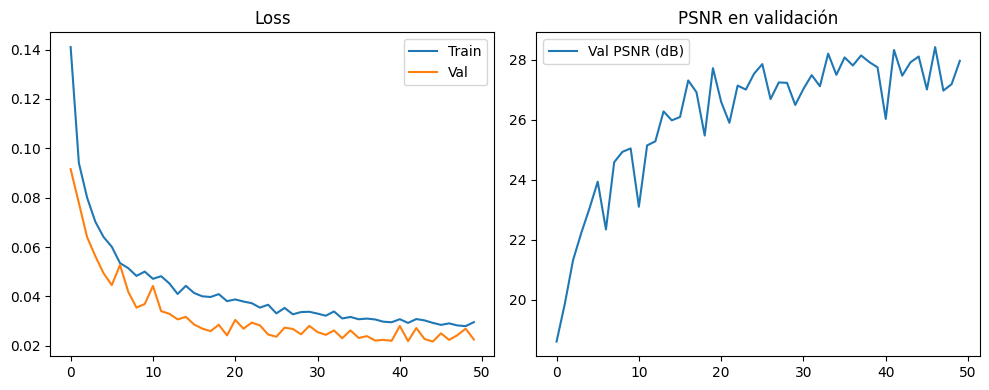

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"],   label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["val_psnr"], label="Val PSNR (dB)")
plt.title("PSNR en validación")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
inpaint_model.load_state_dict(torch.load("best_inpainting_unet.pth", map_location=device))
inpaint_model.eval()

test_loss, test_psnr = step_inpaint(test_loader, inpaint_model, optimizer=None, train=False)
print(f"TEST → Loss {test_loss:.4f} | PSNR {test_psnr:.2f} dB")

  0%|          | 0/9 [00:00<?, ?it/s]

TEST → Loss 0.0222 | PSNR 28.47 dB


### Visualización de resultados del modelo en el conjunto de prueba

Esta celda permite evaluar cualitativamente el desempeño del modelo ya entrenado sobre ejemplos aleatorios del conjunto de *test*.  

Las acciones principales que realiza son:

1. **Función `to_np_img`**  
   Convierte tensores PyTorch en formato `(C, H, W)` a arreglos NumPy `(H, W, C)` para poder graficarlos correctamente con `matplotlib`.

2. **Selección de imágenes aleatorias del `test_ds`**  
   Para cada una de 4 filas de la figura:
   - Se toma un ejemplo aleatorio (`random.choice(test_ds)`).
   - Se pasa la imagen con huecos por el modelo en modo *no gradiente* (`torch.no_grad()`).

3. **Obtención de la reconstrucción del modelo**  
   - Se aplica `sigmoid` para obtener la imagen reconstruida en rango `[0,1]`.
   - Se convierten entrada, predicción y ground truth a formato NumPy.

4. **Visualización lado a lado**  
   Para cada ejemplo se muestran tres imágenes:
   - **Entrada (huecos)**: imagen que recibe la UNet con partes faltantes.  
   - **Salida UNet (rellenado)**: resultado generado por el modelo.  
   - **Target (GT)**: imagen completa original para comparación.

Esto facilita observar cómo el modelo reconstruye regiones faltantes y comparar visualmente la calidad del inpainting.


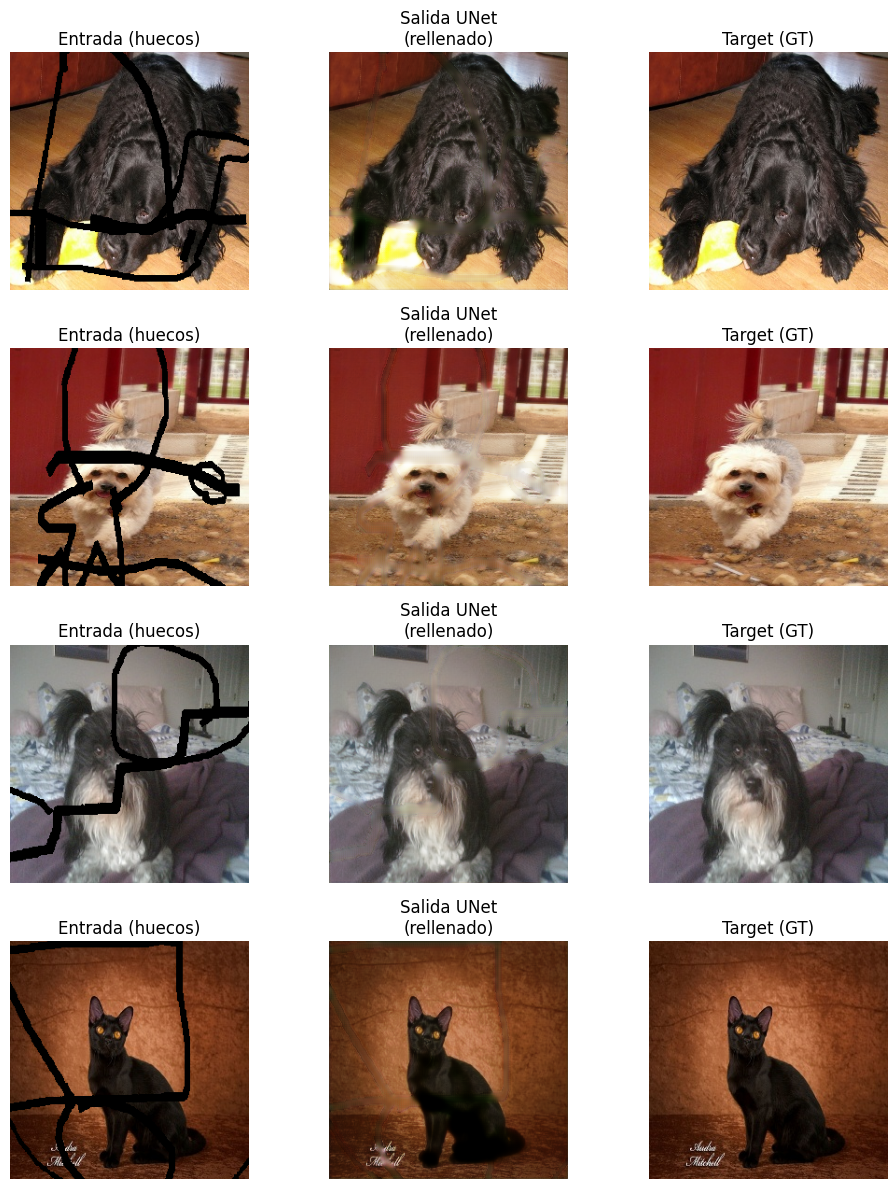

In [15]:
def to_np_img(t):
    # (C,H,W) → (H,W,C)
    return t.permute(1,2,0).cpu().numpy()

fig, axes = plt.subplots(4, 3, figsize=(10, 12))
axes = axes.reshape(-1, 3)

with torch.no_grad():
    for i in range(4):
        img_holes, img_full, mask_inv = random.choice(test_ds)

        x = img_holes.unsqueeze(0).to(device)
        logits = inpaint_model(x)
        pred = torch.sigmoid(logits)[0]

        img_holes_np = to_np_img(img_holes)
        img_full_np  = to_np_img(img_full)
        pred_np      = to_np_img(pred)

        axes[i,0].imshow(img_holes_np)
        axes[i,0].set_title("Entrada (huecos)")
        axes[i,0].axis("off")

        axes[i,1].imshow(pred_np)
        axes[i,1].set_title("Salida UNet\n(rellenado)")
        axes[i,1].axis("off")

        axes[i,2].imshow(img_full_np)
        axes[i,2].set_title("Target (GT)")
        axes[i,2].axis("off")

plt.tight_layout()
plt.show()